In [1]:
from pathlib import Path
import os
import re

import pandas as pd
from pymongo import MongoClient

MONGO_URI = "mongodb://localhost:27017/"
DB_NAME = "unicorn_db"
RAW_COLLECTION = "companies"
CLEAN_COLLECTION = "companies_clean"

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data" / "Unicorn_Companies.csv").exists():
    ROOT_DIR = ROOT_DIR.parent

CSV_PATH = ROOT_DIR / "data" / "Unicorn_Companies.csv"
CHART_DIR = ROOT_DIR / "outputs" / "charts"
MPLCONFIGDIR = ROOT_DIR / ".matplotlib-cache"
CHART_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
client.admin.command("ping")
db = client[DB_NAME]
print(f"Connected to MongoDB at {MONGO_URI}")

Matplotlib is building the font cache; this may take a moment.


Connected to MongoDB at mongodb://localhost:27017/


In [2]:
raw_df = pd.read_csv(CSV_PATH)
if "Select Inverstors" in raw_df.columns and "Select Investors" not in raw_df.columns:
    raw_df = raw_df.rename(columns={"Select Inverstors": "Select Investors"})

display(raw_df.head())
display(raw_df.describe(include="all"))
raw_df.info()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Founded Year,Total Raised,Financial Stage,Investors Count,Deal Terms,Portfolio Exits
0,Bytedance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2012.0,$7.44B,IPO,28.0,8.0,5.0
1,SpaceX,$100.3,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2002.0,$6.874B,NaN,29.0,12.0,NaN
2,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2010.0,$2.901B,Asset,39.0,12.0,1.0
3,Klarna,$45.6,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005.0,$3.472B,Acquired,56.0,13.0,1.0
4,Epic Games,$42,10/26/2018,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991.0,$4.377B,Acquired,25.0,5.0,2.0


,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Founded Year,Total Raised,Financial Stage,Investors Count,Deal Terms,Portfolio Exits
count,1037,1037,1037,1037,1037,1037,1020,994.000000,1013,49,1036.000000,1008.000000,49.000000
unique,1035,200,623,46,256,33,1005,NaN,913,9,NaN,NaN,NaN
top,Bolt,$1,7/13/2021,United States,San Francisco,Fintech,Sequoia Capital,NaN,$300M,Acquired,NaN,NaN,NaN
freq,2,244,9,536,145,205,3,NaN,9,22,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.710262,NaN,NaN,14.432432,3.093254,1.346939
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.942876,NaN,NaN,9.946537,2.159764,0.751416
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1919.000000,NaN,NaN,1.000000,1.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN,8.000000,1.000000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,NaN,13.000000,3.000000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,19.000000,4.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1037 non-null   str    
 1   Valuation ($B)    1037 non-null   str    
 2   Date Joined       1037 non-null   str    
 3   Country           1037 non-null   str    
 4   City              1037 non-null   str    
 5   Industry          1037 non-null   str    
 6   Select Investors  1020 non-null   str    
 7   Founded Year      994 non-null    float64
 8   Total Raised      1013 non-null   str    
 9   Financial Stage   49 non-null     str    
 10  Investors Count   1036 non-null   float64
 11  Deal Terms        1008 non-null   float64
 12  Portfolio Exits   49 non-null     float64
dtypes: float64(4), str(9)
memory usage: 105.4 KB


In [3]:
COLUMN_RENAMES = {
    "Company": "company",
    "Valuation ($B)": "valuation_b",
    "Date Joined": "date_joined",
    "Country": "country",
    "City": "city",
    "Industry": "industry",
    "Select Investors": "select_investors",
    "Select Inverstors": "select_investors",
    "Founded Year": "founded_year",
    "Total Raised": "total_raised",
    "Financial Stage": "financial_stage",
    "Investors Count": "investors_count",
    "Deal Terms": "deal_terms",
    "Portfolio Exits": "portfolio_exits",
}

INDUSTRY_CANONICAL_NAMES = {
    "artificial intelligence": "Artificial intelligence",
}

def parse_valuation(value):
    if pd.isna(value):
        return pd.NA
    cleaned = re.sub(r"[^0-9.]", "", str(value))
    return float(cleaned) if cleaned else pd.NA

# Store the raw CSV rows in MongoDB for the ingestion stage.
raw_records = raw_df.where(pd.notnull(raw_df), None).to_dict(orient="records")
db[RAW_COLLECTION].delete_many({})
if raw_records:
    db[RAW_COLLECTION].insert_many(raw_records)

# Rename columns to Python-friendly field names used by MongoDB queries.
clean_df = raw_df.rename(columns=COLUMN_RENAMES).copy()

# Strip text fields and merge small naming variants such as Artificial Intelligence casing.
for column in ["company", "country", "city", "industry", "select_investors"]:
    if column in clean_df.columns:
        clean_df[column] = clean_df[column].astype("string").str.strip()
clean_df["industry"] = clean_df["industry"].str.lower().map(INDUSTRY_CANONICAL_NAMES).fillna(clean_df["industry"])

# Strip currency symbols and convert valuation strings such as '$140' to floats in billions.
clean_df["valuation_b"] = clean_df["valuation_b"].apply(parse_valuation)
clean_df["valuation_b"] = pd.to_numeric(clean_df["valuation_b"], errors="coerce")

# Parse the date the company became a unicorn and extract the joining year.
clean_df["date_joined"] = pd.to_datetime(clean_df["date_joined"], errors="coerce")
clean_df["year_joined"] = clean_df["date_joined"].dt.year

# Convert founded year to an integer and calculate how long each company took to become a unicorn.
clean_df["founded_year"] = pd.to_numeric(clean_df["founded_year"], errors="coerce")
clean_df["years_to_unicorn"] = clean_df["year_joined"] - clean_df["founded_year"]

critical_fields = [
    "company",
    "valuation_b",
    "date_joined",
    "year_joined",
    "country",
    "industry",
    "founded_year",
    "years_to_unicorn",
]

before_drop = len(clean_df)
clean_df = clean_df.dropna(subset=critical_fields).copy()
for column in ["founded_year", "year_joined", "years_to_unicorn"]:
    clean_df[column] = clean_df[column].round().astype(int)

# Store the cleaned records in a separate MongoDB collection for analysis.
clean_records = clean_df.astype(object).where(pd.notna(clean_df), None).to_dict(orient="records")
db[CLEAN_COLLECTION].delete_many({})
if clean_records:
    db[CLEAN_COLLECTION].insert_many(clean_records)

print(f"Rows before cleaning: {before_drop:,}")
print(f"Rows after cleaning: {len(clean_df):,}")
print(f"Rows dropped: {before_drop - len(clean_df):,}")
display(clean_df.head())

Rows before cleaning: 1,037
Rows after cleaning: 994
Rows dropped: 43


,company,valuation_b,date_joined,country,city,industry,select_investors,founded_year,total_raised,financial_stage,investors_count,deal_terms,portfolio_exits,year_joined,years_to_unicorn
0,Bytedance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2012,$7.44B,IPO,28.0,8.0,5.0,2017,5
1,SpaceX,100.3,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2002,$6.874B,NaN,29.0,12.0,NaN,2012,10
2,Stripe,95.0,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2010,$2.901B,Asset,39.0,12.0,1.0,2014,4
3,Klarna,45.6,2011-12-12,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005,$3.472B,Acquired,56.0,13.0,1.0,2011,6
4,Epic Games,42.0,2018-10-26,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991,$4.377B,Acquired,25.0,5.0,2.0,2018,27


In [4]:
collection = db[CLEAN_COLLECTION]

def print_rows(title, rows):
    print("\n" + title)
    print("=" * len(title))
    for row in rows:
        print(row)

industry_pipeline = [
    {"$group": {"_id": "$industry", "count": {"$sum": 1}}},
    {"$sort": {"count": -1, "_id": 1}},
    {"$limit": 10},
]

country_pipeline = [
    {"$group": {"_id": "$country", "count": {"$sum": 1}}},
    {"$sort": {"count": -1, "_id": 1}},
    {"$limit": 10},
]

unicorns_per_year_pipeline = [
    {"$group": {"_id": "$year_joined", "count": {"$sum": 1}}},
    {"$sort": {"_id": 1}},
]

fastest_industries_2020_2022_pipeline = [
    {"$match": {"year_joined": {"$gte": 2020, "$lte": 2022}}},
    {"$group": {"_id": "$industry", "new_unicorns_2020_2022": {"$sum": 1}}},
    {"$sort": {"new_unicorns_2020_2022": -1, "_id": 1}},
    {"$limit": 10},
]

time_to_unicorn_pipeline = [
    {"$group": {
        "_id": "$industry",
        "company_count": {"$sum": 1},
        "avg_years_to_unicorn": {"$avg": "$years_to_unicorn"},
        "avg_valuation_b": {"$avg": "$valuation_b"},
    }},
    {"$match": {"company_count": {"$gte": 5}}},
    {"$sort": {"avg_years_to_unicorn": 1, "company_count": -1}},
]

print_rows("1. Industry Analysis - Top 10 Industries", list(collection.aggregate(industry_pipeline)))
print_rows("2. Geographic Distribution - Top 10 Countries", list(collection.aggregate(country_pipeline)))
print_rows("3A. New Unicorns Created Per Year", list(collection.aggregate(unicorns_per_year_pipeline)))
print_rows("3B. Fastest Industries from 2020 to 2022", list(collection.aggregate(fastest_industries_2020_2022_pipeline)))
print_rows("4. Time to Unicorn and Average Valuation by Industry", list(collection.aggregate(time_to_unicorn_pipeline)))


1. Industry Analysis - Top 10 Industries
{'_id': 'Fintech', 'count': 193}
{'_id': 'Internet software & services', 'count': 184}
{'_id': 'E-commerce & direct-to-consumer', 'count': 102}
{'_id': 'Artificial intelligence', 'count': 76}
{'_id': 'Health', 'count': 67}
{'_id': 'Supply chain, logistics, & delivery', 'count': 55}
{'_id': 'Other', 'count': 54}
{'_id': 'Cybersecurity', 'count': 48}
{'_id': 'Data management & analytics', 'count': 41}
{'_id': 'Mobile & telecommunications', 'count': 35}

2. Geographic Distribution - Top 10 Countries
{'_id': 'United States', 'count': 517}
{'_id': 'China', 'count': 155}
{'_id': 'India', 'count': 61}
{'_id': 'United Kingdom', 'count': 40}
{'_id': 'Germany', 'count': 24}
{'_id': 'France', 'count': 23}
{'_id': 'Israel', 'count': 20}
{'_id': 'Canada', 'count': 18}
{'_id': 'Brazil', 'count': 15}
{'_id': 'Singapore', 'count': 11}

3A. New Unicorns Created Per Year
{'_id': 2011, 'count': 2}
{'_id': 2012, 'count': 4}
{'_id': 2013, 'count': 3}
{'_id': 2014, 

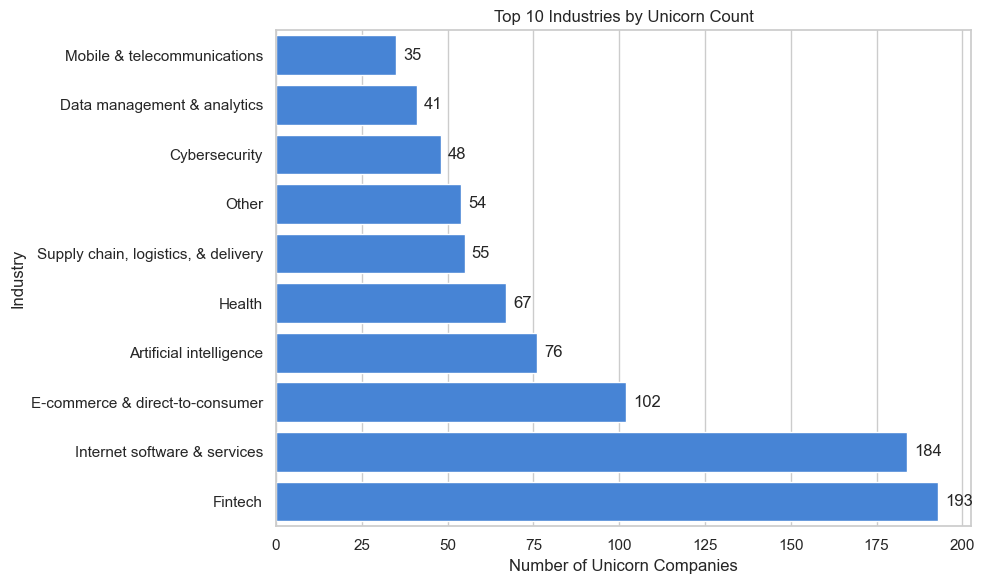

In [5]:
industry_counts = clean_df["industry"].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=industry_counts.values, y=industry_counts.index, ax=ax, color="#2f80ed")
ax.set_title("Top 10 Industries by Unicorn Count")
ax.set_xlabel("Number of Unicorn Companies")
ax.set_ylabel("Industry")
for patch in ax.patches:
    ax.annotate(f"{patch.get_width():.0f}", (patch.get_width(), patch.get_y() + patch.get_height() / 2), xytext=(5, 0), textcoords="offset points", va="center")
fig.tight_layout()
fig.savefig(CHART_DIR / "01_industry_count.png", dpi=300, bbox_inches="tight")
plt.show()

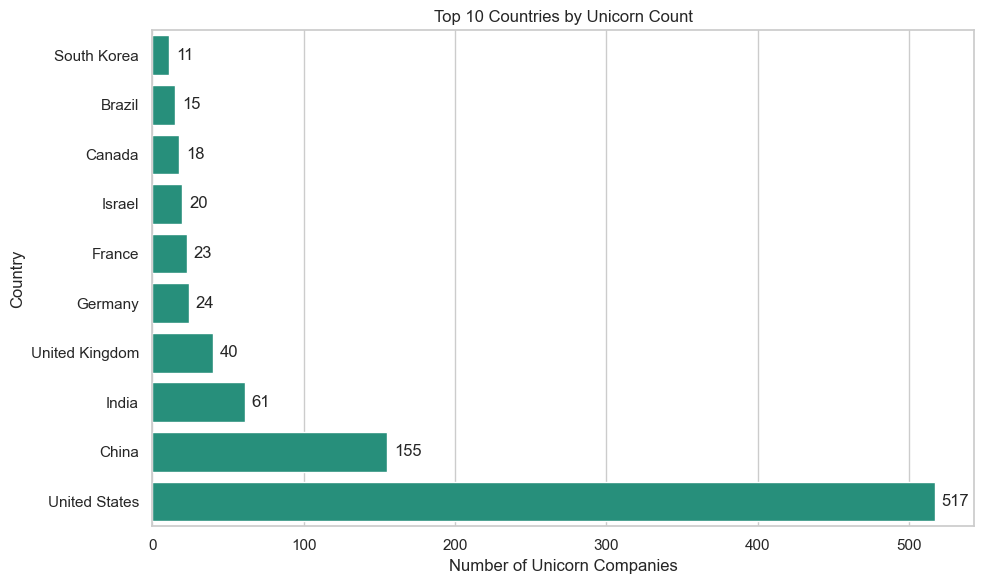

In [6]:
country_counts = clean_df["country"].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, ax=ax, color="#16a085")
ax.set_title("Top 10 Countries by Unicorn Count")
ax.set_xlabel("Number of Unicorn Companies")
ax.set_ylabel("Country")
for patch in ax.patches:
    ax.annotate(f"{patch.get_width():.0f}", (patch.get_width(), patch.get_y() + patch.get_height() / 2), xytext=(5, 0), textcoords="offset points", va="center")
fig.tight_layout()
fig.savefig(CHART_DIR / "02_country_count.png", dpi=300, bbox_inches="tight")
plt.show()

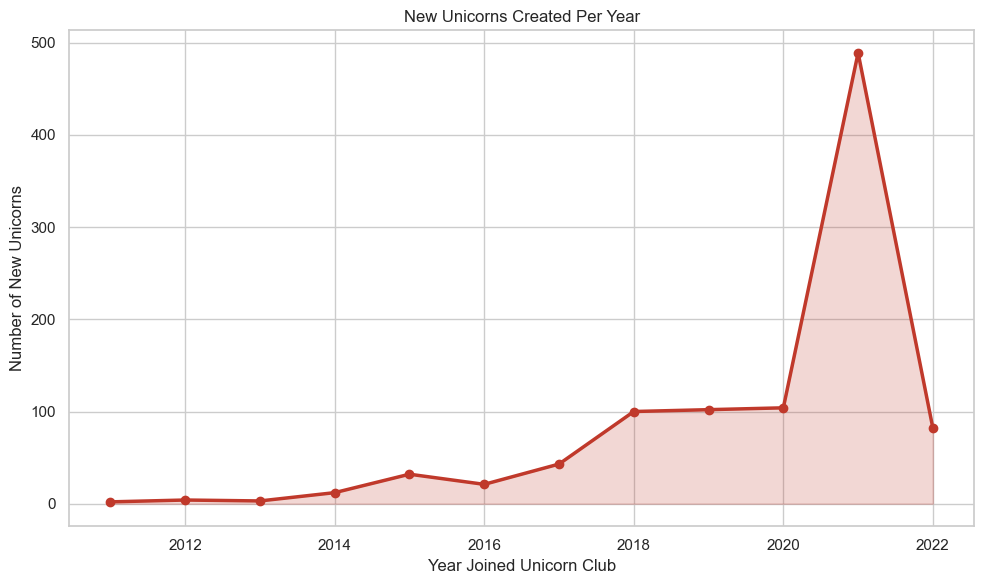

In [7]:
year_counts = clean_df.groupby("year_joined").size().sort_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(year_counts.index, year_counts.values, marker="o", linewidth=2.5, color="#c0392b")
ax.fill_between(year_counts.index, year_counts.values, alpha=0.2, color="#c0392b")
ax.set_title("New Unicorns Created Per Year")
ax.set_xlabel("Year Joined Unicorn Club")
ax.set_ylabel("Number of New Unicorns")
fig.tight_layout()
fig.savefig(CHART_DIR / "03_unicorns_per_year.png", dpi=300, bbox_inches="tight")
plt.show()

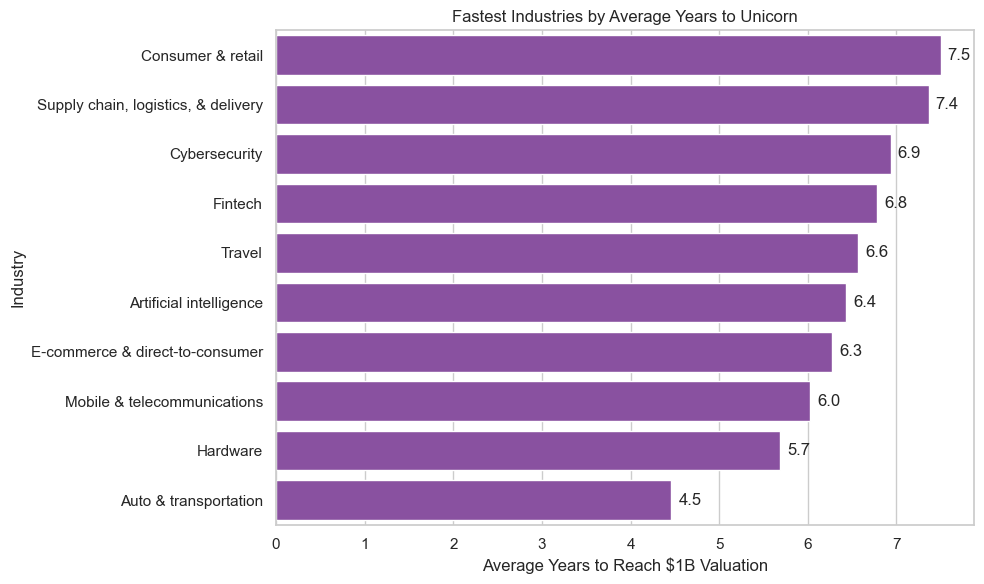

In [8]:
time_data = (
    clean_df.groupby("industry")
    .agg(avg_years_to_unicorn=("years_to_unicorn", "mean"), company_count=("company", "count"))
    .query("company_count >= 5")
    .sort_values("avg_years_to_unicorn")
    .head(10)
    .sort_values("avg_years_to_unicorn", ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=time_data["avg_years_to_unicorn"], y=time_data.index, ax=ax, color="#8e44ad")
ax.set_title("Fastest Industries by Average Years to Unicorn")
ax.set_xlabel("Average Years to Reach $1B Valuation")
ax.set_ylabel("Industry")
for patch in ax.patches:
    ax.annotate(f"{patch.get_width():.1f}", (patch.get_width(), patch.get_y() + patch.get_height() / 2), xytext=(5, 0), textcoords="offset points", va="center")
fig.tight_layout()
fig.savefig(CHART_DIR / "04_time_to_unicorn.png", dpi=300, bbox_inches="tight")
plt.show()

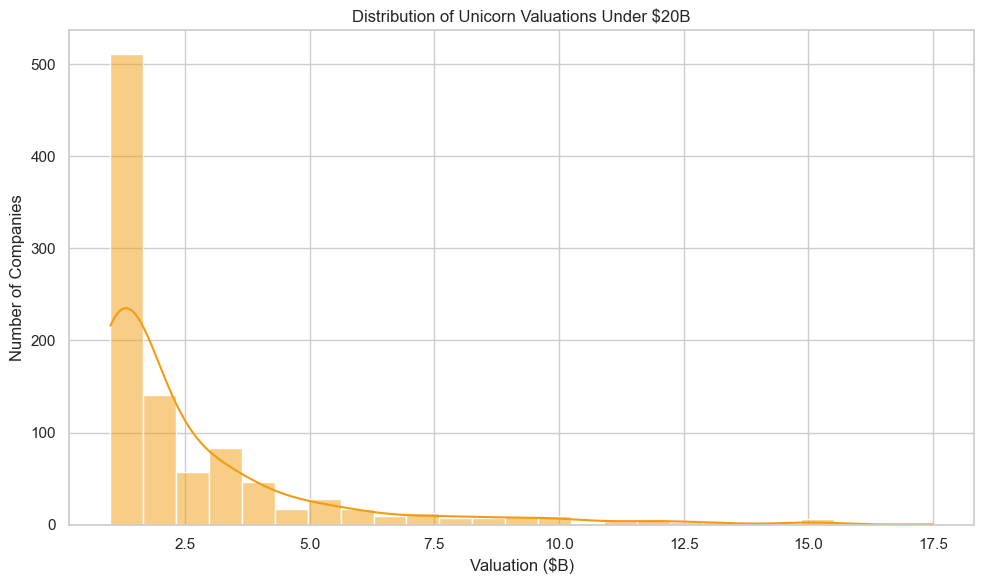

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(clean_df.loc[clean_df["valuation_b"] < 20, "valuation_b"], bins=25, kde=True, ax=ax, color="#f39c12")
ax.set_title("Distribution of Unicorn Valuations Under $20B")
ax.set_xlabel("Valuation ($B)")
ax.set_ylabel("Number of Companies")
fig.tight_layout()
fig.savefig(CHART_DIR / "05_valuation_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

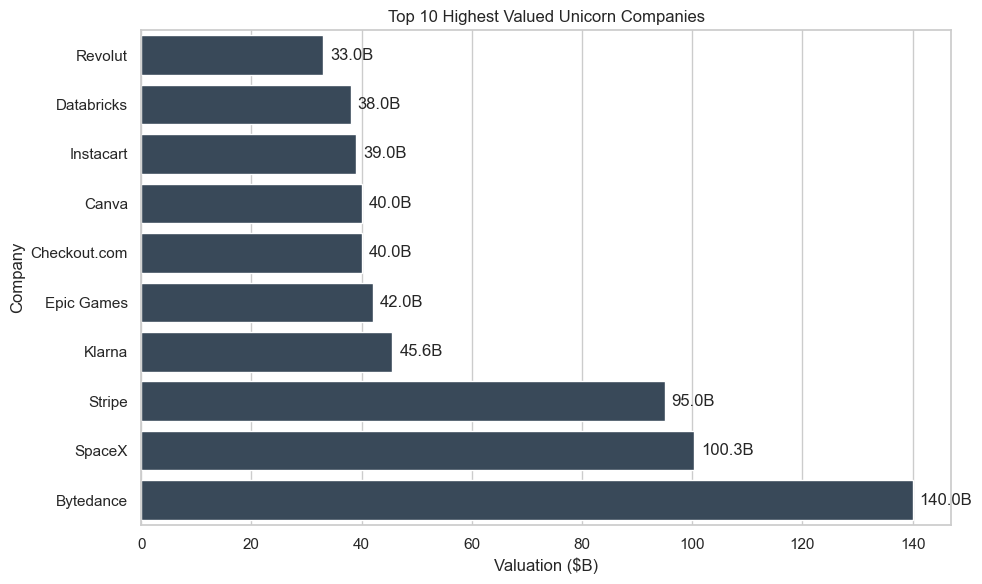

In [10]:
top_valued = clean_df.nlargest(10, "valuation_b").sort_values("valuation_b")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_valued["valuation_b"], y=top_valued["company"], ax=ax, color="#34495e")
ax.set_title("Top 10 Highest Valued Unicorn Companies")
ax.set_xlabel("Valuation ($B)")
ax.set_ylabel("Company")
for patch in ax.patches:
    ax.annotate(f"{patch.get_width():.1f}B", (patch.get_width(), patch.get_y() + patch.get_height() / 2), xytext=(5, 0), textcoords="offset points", va="center")
fig.tight_layout()
fig.savefig(CHART_DIR / "06_top_valued.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusions

### 1. Industry Patterns

The unicorn market is concentrated in technology-heavy categories. Fintech, internet software and services, e-commerce, artificial intelligence, health, and supply-chain related industries appear frequently in the top industry rankings. This shows that unicorn creation is strongest in sectors where software, network effects, data, and scalable platforms can create rapid global growth.

### 2. Geographic Distribution

The geographic distribution is highly concentrated. The United States is the leading unicorn ecosystem, followed by other large innovation markets such as China, India, the United Kingdom, and Germany. This reflects the importance of venture capital availability, technical talent, large domestic markets, and mature startup infrastructure.

### 3. Fastest Growing Sectors

The yearly trend shows that unicorn creation accelerated strongly in the late 2010s and especially around 2020-2022. During this period, fintech and software-driven industries grew quickly as digital payments, remote work, cloud platforms, online commerce, and AI adoption expanded. The 2020-2022 industry pipeline highlights which sectors benefited most from this startup funding cycle.

### 4. Time to Unicorn

Average years to unicorn varies by industry. Some sectors can scale faster because products are digital, distribution is global, and marginal costs are low. Other sectors take longer because they require heavier operations, regulation, hardware, logistics, or scientific development. Comparing average valuation by industry adds context: a sector can produce many unicorns while still having lower average valuations than industries with fewer but larger companies.

Overall, the analysis shows that unicorn startups are not evenly distributed across industries or countries. They cluster where technology scalability, venture capital, market size, and startup infrastructure combine most effectively.